# MGEO DIV30 and DIV90 Analysis

Notebook focused on loading and analyzing MGEO DIV30 and DIV90 cached AnnData objects using the same existing project modules and workflow.

## Analysis Contract

- Reuse existing mge_organoid_python modules and functions only.
- Load cached DIV30 and DIV90 AnnData objects.
- Keep object-based workflow using StudySpec from default_studies().
- Do not add new conversion or loading implementations.

## 1. Imports And Paths

In [12]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.stats import spearmanr

import scanpy as sc

cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent]
if len(cwd.parents) >= 2:
    candidate_roots.append(cwd.parents[1])

for root in candidate_roots:
    src = root / "python_notebooks" / "src"
    if src.exists():
        sys.path.insert(0, str(src))
        repo_root = root
        break
else:
    raise RuntimeError("Could not locate python_notebooks/src from the current notebook directory")

from mge_organoid_python import default_studies, load_cached_anndata, resolve_project_root

PROJECT_ROOT = resolve_project_root()
table_s5_path = PROJECT_ROOT / "reference/shi_2021_tables_s2_to_s9/science.abj6641_table_s5.xlsx"

print("repo_root =", repo_root)
print("PROJECT_ROOT =", PROJECT_ROOT)
print("Table S5 =", table_s5_path)

repo_root = /home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline
PROJECT_ROOT = /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder
Table S5 = /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/reference/shi_2021_tables_s2_to_s9/science.abj6641_table_s5.xlsx


## 2. Load Cached DIV30 And DIV90 AnnData

This loads the already converted `.h5ad` files. It does not rebuild them.

In [13]:
studies = {study.study_id: study for study in default_studies()}

div30, div30_report = load_cached_anndata(studies["varela_div30"], backed=None)
div90, div90_report = load_cached_anndata(studies["varela_div90"], backed=None)

print("DIV30:", div30.shape)
print("DIV90:", div90.shape)
print("DIV30 obs columns:", list(div30.obs.columns))
print("DIV90 obs columns:", list(div90.obs.columns))
print("DIV30 obsm keys:", list(div30.obsm.keys()))
print("DIV90 obsm keys:", list(div90.obsm.keys()))

DIV30: (90631, 18082)
DIV90: (22338, 18082)
DIV30 obs columns: ['cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.2', 'seurat_clusters']
DIV90 obs columns: ['cell_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'CC.Difference', 'RNA_snn_res.0.5', 'seurat_clusters', 'cluster_id', 'cluster_number_name']
DIV30 obsm keys: ['X_umap']
DIV90 obsm keys: ['X_umap']


## 3. Quality Control Object (Wrangling vs Plotting)

This section defines a reusable QC object that handles DIV30 and DIV90 separately, with explicit method separation for data wrangling and plotting.

In [23]:
import seaborn as sns

class QualityControl:
    def __init__(self, adata_by_sample):
        self.adata_by_sample = adata_by_sample
        self.sample_col_priority = [
            "orig.ident",
            "orig_ident",
            "sample",
            "sample_id",
            "Sample",
            "library",
            "batch",
            "donor",
        ]
        self.sample_metadata_df = self._build_sample_metadata()
        self.sample_to_div = dict(zip(self.sample_metadata_df["Sample"], self.sample_metadata_df["DIV"]))
        self.sample_to_object = dict(zip(self.sample_metadata_df["Sample"], self.sample_metadata_df["ObjectKey"]))
        self.div_to_samples = (
            self.sample_metadata_df.groupby("DIV")["Sample"]
            .apply(list)
            .to_dict()
        )
        self.object_to_samples = (
            self.sample_metadata_df.groupby("ObjectKey")["Sample"]
            .apply(list)
            .to_dict()
        )
        self.initial_state_checks = self._run_initial_data_state_checks()

    def _infer_sample_column(self, obs):
        for col in self.sample_col_priority:
            if col in obs.columns and obs[col].nunique(dropna=True) > 1:
                return col
        return None

    def _check_processed_umap_state(self, label, adata):
        x = adata.X
        if sparse.issparse(x):
            data = x.data
            nnz = x.nnz
            total = x.shape[0] * x.shape[1]
            frac_integer = float(np.mean(np.isclose(data, np.round(data)))) if nnz > 0 else float("nan")
            min_nonzero = float(data.min()) if nnz > 0 else float("nan")
            max_nonzero = float(data.max()) if nnz > 0 else float("nan")
        else:
            arr = np.asarray(x)
            nonzero = arr[arr != 0]
            nnz = int(nonzero.size)
            total = arr.size
            frac_integer = float(np.mean(np.isclose(nonzero, np.round(nonzero)))) if nnz > 0 else float("nan")
            min_nonzero = float(nonzero.min()) if nnz > 0 else float("nan")
            max_nonzero = float(nonzero.max()) if nnz > 0 else float("nan")

        has_umap = "X_umap" in adata.obsm
        has_qc_cols = all(
            c in adata.obs.columns
            for c in ["nCount_RNA", "nFeature_RNA", "percent.mt", "seurat_clusters"]
        )
        non_integer_like = bool(frac_integer < 0.1) if not np.isnan(frac_integer) else False
        processed_umap_like = bool(has_umap and has_qc_cols and non_integer_like)

        return {
            "label": label,
            "shape": tuple(adata.shape),
            "has_umap": has_umap,
            "has_qc_cols": has_qc_cols,
            "non_integer_like": non_integer_like,
            "processed_umap_like": processed_umap_like,
            "min_nonzero": min_nonzero,
            "max_nonzero": max_nonzero,
            "matrix_sparsity": float(1 - (nnz / total)),
        }

    def _run_initial_data_state_checks(self):
        checks = {}
        print("Initial data-state checks:")
        for label, adata in self.adata_by_sample.items():
            report = self._check_processed_umap_state(label, adata)
            checks[label] = report
            print(
                f"- {label}: processed_umap_like={report['processed_umap_like']} "
                f"(has_umap={report['has_umap']}, has_qc_cols={report['has_qc_cols']}, "
                f"non_integer_like={report['non_integer_like']})"
            )
        return checks

    def _build_sample_metadata(self):
        records = []
        for object_key, adata in self.adata_by_sample.items():
            obs = adata.obs.copy()
            sample_col = self._infer_sample_column(obs)
            if sample_col is None:
                sample_values = [str(object_key)]
            else:
                sample_values = sorted(obs[sample_col].astype(str).dropna().unique().tolist())

            for sample_name in sample_values:
                records.append(
                    {
                        "ObjectKey": str(object_key),
                        "DIV": str(object_key),
                        "Sample": str(sample_name),
                        "SampleColumn": sample_col if sample_col is not None else "<object_key>",
                    }
                )

        return pd.DataFrame(records)

    def wrangle_metrics(self):
        frames = []
        for div_label, adata in self.adata_by_sample.items():
            tmp = adata.copy()
            tmp.var["mt"] = tmp.var_names.str.upper().str.startswith("MT-")
            sc.pp.calculate_qc_metrics(
                tmp,
                qc_vars=["mt"],
                percent_top=[20],
                log1p=True,
                inplace=True,
            )

            obs = tmp.obs.copy()
            sample_col = self._infer_sample_column(obs)
            if sample_col is None:
                sample_series = pd.Series(div_label, index=obs.index)
            else:
                sample_series = obs[sample_col].astype(str)

            if "n_genes" not in obs.columns and "n_genes_by_counts" in obs.columns:
                obs["n_genes"] = obs["n_genes_by_counts"]

            keep = [
                "total_counts",
                "log1p_total_counts",
                "n_genes_by_counts",
                "n_genes",
                "pct_counts_mt",
                "pct_counts_in_top_20_genes",
            ]
            keep = [col for col in keep if col in obs.columns]
            frame = obs[keep].copy()
            frame["DIV"] = str(div_label)
            frame["Sample"] = sample_series.values
            frame["ObjectKey"] = str(div_label)
            frames.append(frame)

        return pd.concat(frames, axis=0, ignore_index=True)

    def make_qc_summary_table(self, df, div_order=None):
        required = ["DIV", "Sample"]
        if not all(c in df.columns for c in required):
            raise ValueError("QC dataframe must include DIV and Sample columns")

        if div_order is not None:
            work = df[df["DIV"].isin(div_order)].copy()
        else:
            div_order = sorted(df["DIV"].unique())
            work = df.copy()

        grouped = work.groupby(["DIV", "Sample"], observed=False)
        summary = grouped.size().rename("n_cells").to_frame()

        metric_map = [
            ("total_counts", "median_total_counts"),
            ("log1p_total_counts", "median_log1p_total_counts"),
            ("n_genes", "median_n_genes"),
            ("pct_counts_mt", "median_pct_counts_mt"),
            ("pct_counts_in_top_20_genes", "median_pct_top20"),
        ]
        for source_col, out_col in metric_map:
            if source_col in work.columns:
                summary[out_col] = grouped[source_col].median()

        summary = summary.reset_index()
        summary["DIV"] = pd.Categorical(summary["DIV"], categories=div_order, ordered=True)
        summary = summary.sort_values(["DIV", "Sample"]).reset_index(drop=True)

        for col in summary.columns:
            if col.startswith("median_"):
                summary[col] = summary[col].round(3)

        fig_height = max(2.5, 0.35 * len(summary) + 1.8)
        fig, ax = plt.subplots(figsize=(12, fig_height))
        ax.axis("off")
        table = ax.table(
            cellText=summary.values,
            colLabels=summary.columns,
            cellLoc="center",
            loc="center",
        )
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 1.25)

        for col_idx in range(len(summary.columns)):
            table[(0, col_idx)].set_facecolor("#E8EEF8")
            table[(0, col_idx)].set_text_props(weight="bold")

        ax.set_title("QC Summary Table By DIV and Sample", fontsize=12, weight="bold", pad=12)
        plt.tight_layout()
        plt.show()

        return summary

    def plot_ridge(self, df, value="log1p_total_counts", sample_order=None):
        if value not in df.columns:
            raise ValueError(f"{value} is not present in the QC dataframe columns")

        if sample_order is None:
            sample_order = sorted(df["Sample"].unique())

        plot_df = df[df["Sample"].isin(sample_order)].copy()
        plot_df["Sample"] = pd.Categorical(plot_df["Sample"], categories=sample_order, ordered=True)
        plot_df = plot_df.sort_values("Sample")

        sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

        g = sns.FacetGrid(
            plot_df,
            row="Sample",
            hue="Sample",
            row_order=sample_order,
            aspect=15,
            height=0.55,
            palette="tab20",
        )

        g.map(sns.kdeplot, value, clip_on=False, fill=True, alpha=1, linewidth=1.5)
        g.map(sns.kdeplot, value, clip_on=False, color="w", lw=2)
        g.map(plt.axhline, y=0, lw=2, clip_on=False)

        def label(x, color, label):
            ax = plt.gca()
            ax.text(
                -0.02,
                0.2,
                label,
                fontweight="bold",
                color=color,
                ha="right",
                va="center",
                transform=ax.transAxes,
                clip_on=False,
            )

        g.map(label, value)
        g.figure.subplots_adjust(left=0.2, hspace=-0.6)
        g.set_titles("")
        g.set(yticks=[], ylabel="")
        g.despine(bottom=True, left=True)

        median_value = plot_df[value].median()
        for ax in g.axes.flat:
            ax.axvline(x=median_value, color="r", linestyle="-")

        g.fig.suptitle(f"QC Ridge Plot: {value}", y=1.02)
        plt.show()

    def plot_by_sample(self, df, value="log1p_total_counts", div_order=None):
        if value not in df.columns:
            raise ValueError(f"{value} is not present in the QC dataframe columns")
        if "DIV" not in df.columns or "Sample" not in df.columns:
            raise ValueError("QC dataframe must include DIV and Sample columns")

        if div_order is None:
            div_order = sorted(df["DIV"].unique())

        sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

        for div_label in div_order:
            div_df = df[df["DIV"] == div_label].copy()
            if div_df.empty:
                continue

            sample_order = sorted(div_df["Sample"].unique())
            div_df["Sample"] = pd.Categorical(div_df["Sample"], categories=sample_order, ordered=True)
            div_df = div_df.sort_values("Sample")

            g = sns.FacetGrid(
                div_df,
                row="Sample",
                hue="Sample",
                row_order=sample_order,
                aspect=14,
                height=0.5,
                palette="tab20",
            )

            g.map(sns.kdeplot, value, clip_on=False, fill=True, alpha=1, linewidth=1.5)
            g.map(sns.kdeplot, value, clip_on=False, color="w", lw=2)
            g.map(plt.axhline, y=0, lw=2, clip_on=False)

            def label(x, color, label):
                ax = plt.gca()
                ax.text(
                    -0.02,
                    0.2,
                    label,
                    fontweight="bold",
                    color=color,
                    ha="right",
                    va="center",
                    transform=ax.transAxes,
                    clip_on=False,
                )

            g.map(label, value)
            g.figure.subplots_adjust(left=0.2, hspace=-0.6)
            g.set_titles("")
            g.set(yticks=[], ylabel="")
            g.despine(bottom=True, left=True)

            for ax, sample in zip(g.axes.flat, sample_order):
                sample_median = div_df.loc[div_df["Sample"] == sample, value].median()
                ax.axvline(x=sample_median, color="r", linestyle="-")

            g.fig.suptitle(f"{div_label}: {value} by sample", y=1.02)
            plt.show()

    def plot_percent_mito_by_sample(self, df, div_order=None):
        self.plot_by_sample(
            df=df,
            value="pct_counts_mt",
            div_order=div_order,
        )

Initial data-state checks:
- DIV30: processed_umap_like=True (has_umap=True, has_qc_cols=True, non_integer_like=True)
- DIV90: processed_umap_like=True (has_umap=True, has_qc_cols=True, non_integer_like=True)
Sample metadata table:


,ObjectKey,DIV,Sample,SampleColumn
0,DIV30,DIV30,9583-MW-1,orig.ident
1,DIV30,DIV30,9583-MW-2,orig.ident
2,DIV30,DIV30,9583-MW-3,orig.ident
3,DIV30,DIV30,9583-MW-4,orig.ident
4,DIV30,DIV30,9583-MW-5,orig.ident
5,DIV30,DIV30,9583-MW-6,orig.ident
6,DIV90,DIV90,10496-MW-1,orig.ident
7,DIV90,DIV90,10496-MW-2,orig.ident
8,DIV90,DIV90,10496-MW-3,orig.ident
9,DIV90,DIV90,10496-MW-4,orig.ident


Initial processed-UMAP checks:


,processed_umap_like,has_umap,has_qc_cols,non_integer_like,min_nonzero,max_nonzero,matrix_sparsity
DIV30,True,True,True,True,0.287849,6.095798,0.757132
DIV90,True,True,True,True,0.594368,7.482219,0.875761


Sample -> DIV map:


10496-MW-1    DIV90
10496-MW-2    DIV90
10496-MW-3    DIV90
10496-MW-4    DIV90
10496-MW-5    DIV90
10496-MW-6    DIV90
9583-MW-1     DIV30
9583-MW-2     DIV30
9583-MW-3     DIV30
9583-MW-4     DIV30
9583-MW-5     DIV30
9583-MW-6     DIV30
Name: DIV, dtype: object

DIV -> samples map:


DIV30    [9583-MW-1, 9583-MW-2, 9583-MW-3, 9583-MW-4, 9...
DIV90    [10496-MW-1, 10496-MW-2, 10496-MW-3, 10496-MW-...
Name: Samples, dtype: object

,DIV,Sample,n_cells
0,DIV30,9583-MW-1,14564
1,DIV30,9583-MW-2,4532
2,DIV30,9583-MW-3,15773
3,DIV30,9583-MW-4,11004
4,DIV30,9583-MW-5,22230
5,DIV30,9583-MW-6,22528
6,DIV90,10496-MW-1,3095
7,DIV90,10496-MW-2,3533
8,DIV90,10496-MW-3,2714
9,DIV90,10496-MW-4,6314


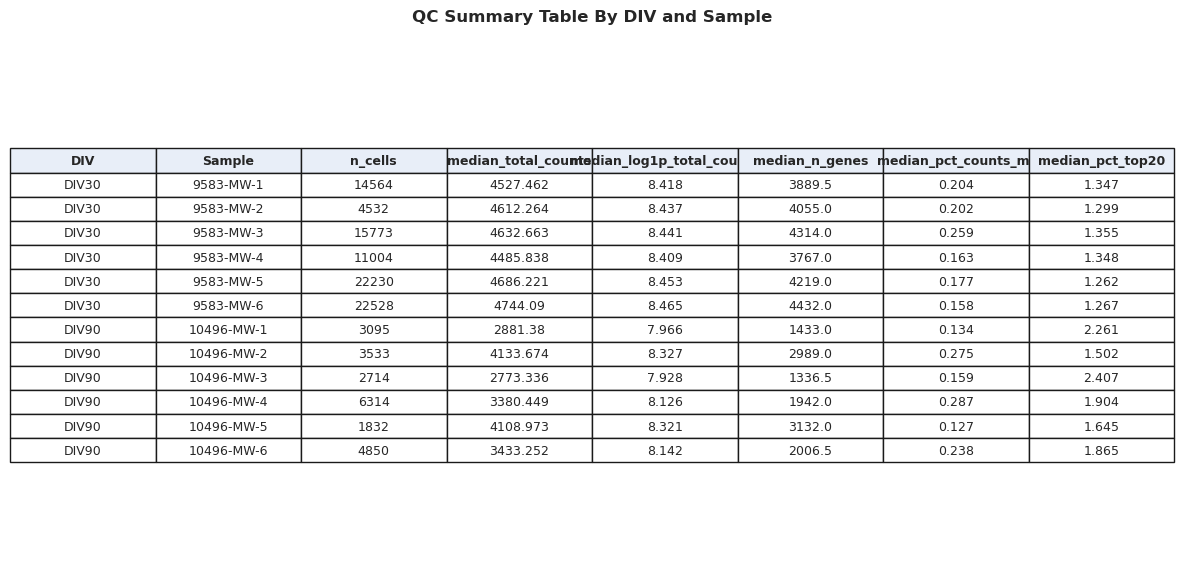

,DIV,Sample,n_cells,median_total_counts,median_log1p_total_counts,median_n_genes,median_pct_counts_mt,median_pct_top20
0,DIV30,9583-MW-1,14564,4527.462,8.418,3889.5,0.204,1.347
1,DIV30,9583-MW-2,4532,4612.264,8.437,4055.0,0.202,1.299
2,DIV30,9583-MW-3,15773,4632.663,8.441,4314.0,0.259,1.355
3,DIV30,9583-MW-4,11004,4485.838,8.409,3767.0,0.163,1.348
4,DIV30,9583-MW-5,22230,4686.221,8.453,4219.0,0.177,1.262
5,DIV30,9583-MW-6,22528,4744.090,8.465,4432.0,0.158,1.267
6,DIV90,10496-MW-1,3095,2881.380,7.966,1433.0,0.134,2.261
7,DIV90,10496-MW-2,3533,4133.674,8.327,2989.0,0.275,1.502
8,DIV90,10496-MW-3,2714,2773.336,7.928,1336.5,0.159,2.407
9,DIV90,10496-MW-4,6314,3380.449,8.126,1942.0,0.287,1.904


/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axe

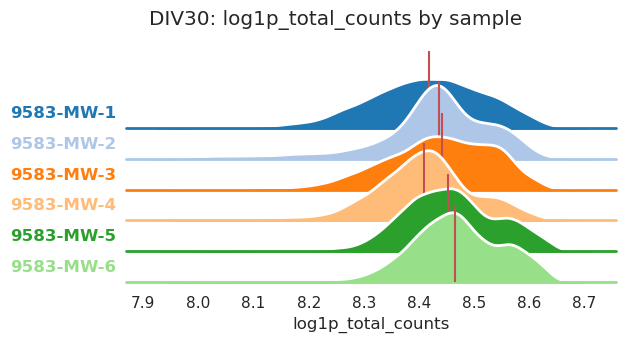

/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axe

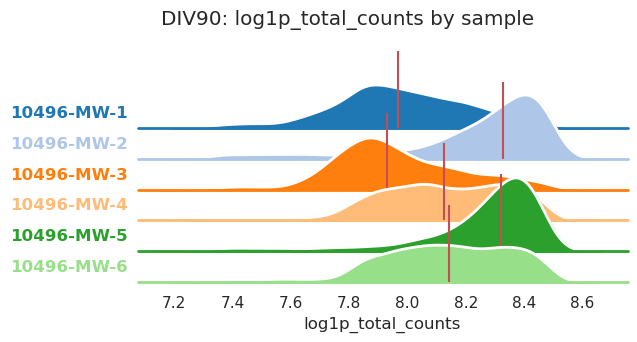

/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axe

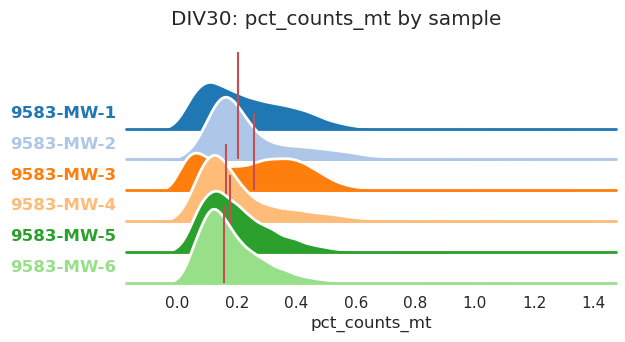

/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axe

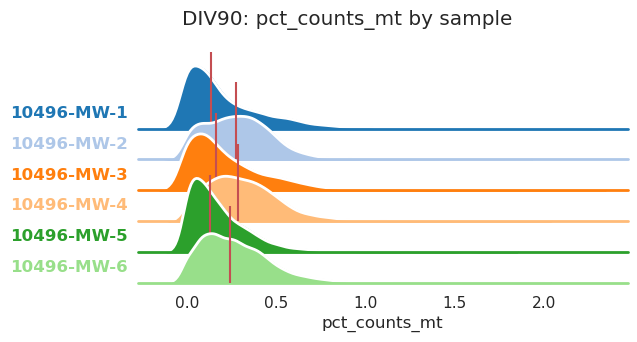

In [24]:
qualitycontrol = QualityControl({
    "DIV30": div30,
    "DIV90": div90,
})

print("Sample metadata table:")
display(qualitycontrol.sample_metadata_df)

print("Initial processed-UMAP checks:")
display(
    pd.DataFrame.from_dict(qualitycontrol.initial_state_checks, orient="index")[
        ["processed_umap_like", "has_umap", "has_qc_cols", "non_integer_like", "min_nonzero", "max_nonzero", "matrix_sparsity"]
    ]
)

print("Sample -> DIV map:")
display(pd.Series(qualitycontrol.sample_to_div, name="DIV").sort_index())

print("DIV -> samples map:")
display(pd.Series(qualitycontrol.div_to_samples, name="Samples").sort_index())

qc_df = qualitycontrol.wrangle_metrics()
display(
    qc_df.groupby(["DIV", "Sample"]).size().rename("n_cells").reset_index()
    .sort_values(["DIV", "Sample"])
    .head(20)
)

qc_summary = qualitycontrol.make_qc_summary_table(
    qc_df,
    div_order=["DIV30", "DIV90"],
)
display(qc_summary)

qualitycontrol.plot_by_sample(
    qc_df,
    value="log1p_total_counts",
    div_order=["DIV30", "DIV90"],
)

qualitycontrol.plot_percent_mito_by_sample(
    qc_df,
    div_order=["DIV30", "DIV90"],
)

## 4. Clustering

This section defines a clustering class that takes the existing QualityControl object as input and reuses its metadata and loaded AnnData objects.

In [34]:
class Clustering:
    def __init__(self, quality_control):
        self.quality_control = quality_control
        self.adata_by_sample = quality_control.adata_by_sample
        self.sample_metadata_df = quality_control.sample_metadata_df.copy()
        self.sample_to_div = dict(quality_control.sample_to_div)
        self.div_to_samples = dict(quality_control.div_to_samples)
        self.adata_concat = None
        self.workflow_backend = "seurat_exported"
        self.scanpy_adatas = {}
        self.scanpy_resolution_results = {}

    def summary(self):
        print("Clustering object initialized.")
        print("Current backend mode:", self.workflow_backend)
        print("DIV groups:", sorted(self.div_to_samples.keys()))
        print("Total samples:", len(self.sample_to_div))
        display(self.sample_metadata_df)

    def activate_scanpy_workflow(self):
        self.workflow_backend = "scanpy"
        print("Scanpy workflow activated.")
        print("From this point, use scanpy_* methods for clustering/UMAP generation.")
        print("This distinguishes new Scanpy outputs from exported Seurat coordinates/labels.")

    def _require_scanpy_workflow(self):
        if self.workflow_backend != "scanpy":
            raise RuntimeError(
                "Scanpy workflow is not active. Run activate_scanpy_workflow() before scanpy_* methods."
            )

    def available_umap_and_cluster_fields(self):
        rows = []
        for div_label, adata in self.adata_by_sample.items():
            obs_cols = list(adata.obs.columns)
            cluster_candidates = [
                c for c in obs_cols
                if "cluster" in c.lower() or "res." in c.lower() or c.lower() in {"ident", "seurat_clusters"}
            ]
            rows.append(
                {
                    "DIV": div_label,
                    "n_cells": int(adata.n_obs),
                    "n_genes": int(adata.n_vars),
                    "has_X_umap": "X_umap" in adata.obsm,
                    "obsm_keys": list(adata.obsm.keys()),
                    "cluster_like_columns": cluster_candidates,
                }
            )
        out = pd.DataFrame(rows)
        print("Available UMAP/cluster fields in current objects:")
        display(out)
        return out

    def plot_umap_with_clusters(
        self,
        cluster_col="seurat_clusters",
        div_order=None,
        point_size=4,
        legend_marker_scale=4,
    ):
        if div_order is None:
            div_order = sorted(self.adata_by_sample.keys())

        for div_label in div_order:
            adata = self.adata_by_sample[div_label]
            if "X_umap" not in adata.obsm:
                print(f"Skipping {div_label}: X_umap not found")
                continue
            if cluster_col not in adata.obs.columns:
                print(f"Skipping {div_label}: {cluster_col} not found in obs")
                continue

            plot_df = pd.DataFrame(adata.obsm["X_umap"], columns=["UMAP1", "UMAP2"], index=adata.obs_names)
            plot_df["cluster"] = adata.obs[cluster_col].astype(str).values

            fig, ax = plt.subplots(figsize=(7, 6), facecolor="white")
            ax.set_facecolor("white")
            sns.scatterplot(
                data=plot_df,
                x="UMAP1",
                y="UMAP2",
                hue="cluster",
                s=point_size,
                linewidth=0,
                alpha=0.8,
                palette="tab20",
                ax=ax,
            )
            ax.set_title(f"{div_label} UMAP colored by {cluster_col} (exported Seurat UMAP)")
            ax.set_xlabel("UMAP 1")
            ax.set_ylabel("UMAP 2")
            legend = ax.legend(
                bbox_to_anchor=(1.02, 1),
                loc="upper left",
                borderaxespad=0,
                title=cluster_col,
                frameon=True,
                markerscale=legend_marker_scale,
            )
            if legend is not None:
                legend.get_frame().set_facecolor("white")
                legend.get_frame().set_edgecolor("0.85")
                legend.get_frame().set_alpha(1.0)
            plt.tight_layout()
            plt.show()

    def scanpy_prepare_inputs(self, div_order=None, make_copy=True):
        self._require_scanpy_workflow()
        if div_order is None:
            div_order = sorted(self.adata_by_sample.keys())

        self.scanpy_adatas = {}
        for div_label in div_order:
            if div_label not in self.adata_by_sample:
                print(f"Skipping missing DIV key: {div_label}")
                continue
            adata = self.adata_by_sample[div_label].copy() if make_copy else self.adata_by_sample[div_label]
            if "X_umap" in adata.obsm:
                adata.obsm["X_umap_seurat"] = adata.obsm["X_umap"].copy()
            self.scanpy_adatas[div_label] = adata

        print("Scanpy inputs prepared for:", sorted(self.scanpy_adatas.keys()))
        print("Use scanpy_compute_graph_and_umap() next.")
        return self.scanpy_adatas

    def scanpy_compute_graph_and_umap(
        self,
        n_top_genes=3000,
        n_pcs=50,
        n_neighbors=20,
        random_state=7,
    ):
        self._require_scanpy_workflow()
        if not self.scanpy_adatas:
            raise RuntimeError("No prepared Scanpy objects found. Run scanpy_prepare_inputs() first.")

        for div_label, adata in self.scanpy_adatas.items():
            sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes, flavor="seurat", subset=False)
            hvg_mask = adata.var["highly_variable"].values
            adata_hvg = adata[:, hvg_mask].copy()
            sc.pp.scale(adata_hvg, max_value=10)
            sc.tl.pca(adata_hvg, n_comps=n_pcs, svd_solver="arpack", random_state=random_state)
            adata.obsm["X_pca_scanpy"] = adata_hvg.obsm["X_pca"]
            sc.pp.neighbors(
                adata,
                n_neighbors=n_neighbors,
                n_pcs=n_pcs,
                use_rep="X_pca_scanpy",
                random_state=random_state,
            )
            sc.tl.umap(adata, random_state=random_state)
            adata.obsm["X_umap_scanpy"] = adata.obsm["X_umap"].copy()
            print(f"{div_label}: Scanpy graph+UMAP complete.")

    def scanpy_leiden_resolution_sweep(self, resolutions=(0.2, 0.4, 0.8, 1.2), key_prefix="leiden"):
        self._require_scanpy_workflow()
        if not self.scanpy_adatas:
            raise RuntimeError("No prepared Scanpy objects found. Run scanpy_prepare_inputs() first.")

        self.scanpy_resolution_results = {}
        for div_label, adata in self.scanpy_adatas.items():
            added = []
            for r in resolutions:
                key = f"{key_prefix}_{r}"
                sc.tl.leiden(adata, resolution=float(r), key_added=key)
                added.append(key)
            self.scanpy_resolution_results[div_label] = added
            print(f"{div_label}: added Leiden keys {added}")

        return self.scanpy_resolution_results

    def prepare_concat(self, join="inner"):
        adatas = []
        for div_label, adata in self.adata_by_sample.items():
            tmp = adata.copy()
            tmp.obs["DIV"] = str(div_label)
            sample_col = self.quality_control._infer_sample_column(tmp.obs)
            if sample_col is None:
                tmp.obs["Sample"] = str(div_label)
            else:
                tmp.obs["Sample"] = tmp.obs[sample_col].astype(str)
            adatas.append(tmp)

        self.adata_concat = ad.concat(
            adatas,
            axis=0,
            join=join,
            merge="same",
        )
        print("Concatenated object shape:", self.adata_concat.shape)
        return self.adata_concat

Clustering object initialized.
Current backend mode: seurat_exported
DIV groups: ['DIV30', 'DIV90']
Total samples: 12


,ObjectKey,DIV,Sample,SampleColumn
0,DIV30,DIV30,9583-MW-1,orig.ident
1,DIV30,DIV30,9583-MW-2,orig.ident
2,DIV30,DIV30,9583-MW-3,orig.ident
3,DIV30,DIV30,9583-MW-4,orig.ident
4,DIV30,DIV30,9583-MW-5,orig.ident
5,DIV30,DIV30,9583-MW-6,orig.ident
6,DIV90,DIV90,10496-MW-1,orig.ident
7,DIV90,DIV90,10496-MW-2,orig.ident
8,DIV90,DIV90,10496-MW-3,orig.ident
9,DIV90,DIV90,10496-MW-4,orig.ident


Available UMAP/cluster fields in current objects:


,DIV,n_cells,n_genes,has_X_umap,obsm_keys,cluster_like_columns
0,DIV30,90631,18082,True,[X_umap],"[RNA_snn_res.0.2, seurat_clusters]"
1,DIV90,22338,18082,True,[X_umap],"[RNA_snn_res.0.5, seurat_clusters, cluster_id,..."


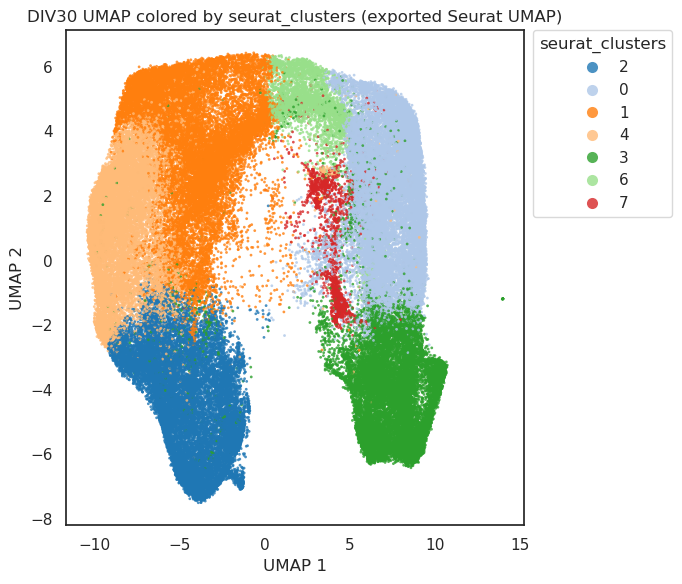

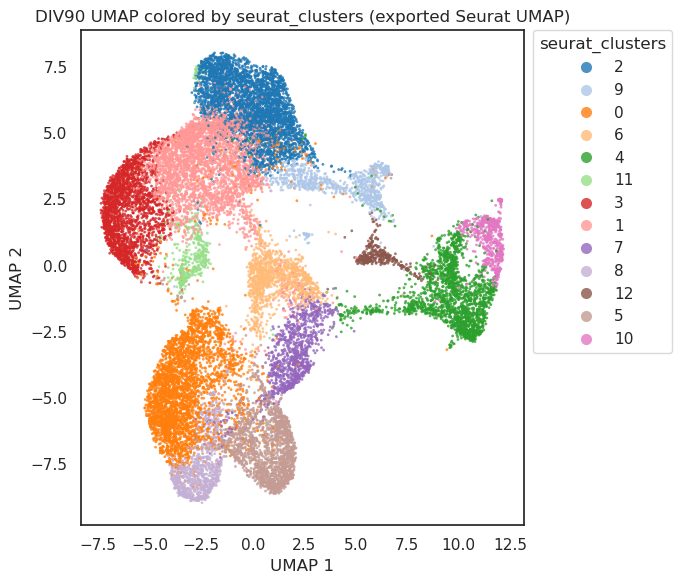

Scanpy workflow activated.
From this point, use scanpy_* methods for clustering/UMAP generation.
This distinguishes new Scanpy outputs from exported Seurat coordinates/labels.
Next Scanpy steps:
1. clustering.scanpy_prepare_inputs(div_order=['DIV30', 'DIV90'])
2. clustering.scanpy_compute_graph_and_umap(...)
3. clustering.scanpy_leiden_resolution_sweep(...)


In [35]:
clustering = Clustering(qualitycontrol)
clustering.summary()

available_fields = clustering.available_umap_and_cluster_fields()

# Exported Seurat UMAP view (existing coordinates)
clustering.plot_umap_with_clusters(
    cluster_col="seurat_clusters",
    div_order=["DIV30", "DIV90"],
)

# Explicit transition into Scanpy-generated workflow
clustering.activate_scanpy_workflow()
print("Next Scanpy steps:")
print("1. clustering.scanpy_prepare_inputs(div_order=['DIV30', 'DIV90'])")
print("2. clustering.scanpy_compute_graph_and_umap(...)")
print("3. clustering.scanpy_leiden_resolution_sweep(...)")

In [31]:
for div_label, adata in clustering.adata_by_sample.items():
    cols = list(adata.obs.columns)
    cluster_like = [
        c for c in cols
        if "cluster" in c.lower() or "res." in c.lower() or c.lower() in {"ident", "seurat_clusters"}
    ]
    print(f"{div_label} exact cluster-like columns: {cluster_like}")
    print(f"{div_label} obsm keys: {list(adata.obsm.keys())}")

DIV30 exact cluster-like columns: ['RNA_snn_res.0.2', 'seurat_clusters']
DIV30 obsm keys: ['X_umap']
DIV90 exact cluster-like columns: ['RNA_snn_res.0.5', 'seurat_clusters', 'cluster_id', 'cluster_number_name']
DIV90 obsm keys: ['X_umap']


In [36]:
# DIV30-only Scanpy clustering resolution test
clustering.activate_scanpy_workflow()
clustering.scanpy_prepare_inputs(div_order=["DIV30"], make_copy=True)
clustering.scanpy_compute_graph_and_umap(
    n_top_genes=3000,
    n_pcs=50,
    n_neighbors=20,
    random_state=7,
)
div30_res = clustering.scanpy_leiden_resolution_sweep(
    resolutions=(0.2, 0.4, 0.8, 1.2),
    key_prefix="leiden_scanpy",
)
print("DIV30 Scanpy Leiden keys:", div30_res.get("DIV30", []))
print("Prepared Scanpy DIVs:", sorted(clustering.scanpy_adatas.keys()))

Scanpy workflow activated.
From this point, use scanpy_* methods for clustering/UMAP generation.
This distinguishes new Scanpy outputs from exported Seurat coordinates/labels.
Scanpy inputs prepared for: ['DIV30']
Use scanpy_compute_graph_and_umap() next.


/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DIV30: Scanpy graph+UMAP complete.


/tmp/ipykernel_3428209/3813133856.py:166: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=float(r), key_added=key)


DIV30: added Leiden keys ['leiden_scanpy_0.2', 'leiden_scanpy_0.4', 'leiden_scanpy_0.8', 'leiden_scanpy_1.2']
DIV30 Scanpy Leiden keys: ['leiden_scanpy_0.2', 'leiden_scanpy_0.4', 'leiden_scanpy_0.8', 'leiden_scanpy_1.2']
Prepared Scanpy DIVs: ['DIV30']


In [ ]:
# Plot DIV30 Scanpy UMAP across tested Leiden resolutions
div_label = "DIV30"
if div_label not in clustering.scanpy_adatas:
    raise RuntimeError("DIV30 not found in scanpy_adatas. Run the DIV30 scanpy prep/compute cell first.")

adata_scanpy = clustering.scanpy_adatas[div_label]
res_keys = clustering.scanpy_resolution_results.get(div_label, [])
if not res_keys:
    raise RuntimeError("No Leiden resolution results found for DIV30. Run scanpy_leiden_resolution_sweep first.")

umap_key = "X_umap_scanpy" if "X_umap_scanpy" in adata_scanpy.obsm else "X_umap"
coords = adata_scanpy.obsm[umap_key]

n_panels = len(res_keys)
ncols = 2 if n_panels > 1 else 1
nrows = int(np.ceil(n_panels / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(6.5 * ncols, 5.8 * nrows),
    facecolor="white",
    squeeze=False,
    constrained_layout=True,
 )
axes = axes.flatten()

for i, key in enumerate(res_keys):
    ax = axes[i]
    if key not in adata_scanpy.obs.columns:
        ax.axis("off")
        ax.set_title(f"Missing: {key}")
        continue

    plot_df = pd.DataFrame(coords, columns=["UMAP1", "UMAP2"], index=adata_scanpy.obs_names)
    plot_df["cluster"] = adata_scanpy.obs[key].astype(str).values

    sns.scatterplot(
        data=plot_df,
        x="UMAP1",
        y="UMAP2",
        hue="cluster",
        s=2,
        linewidth=0,
        alpha=0.85,
        palette="tab20",
        ax=ax,
        legend=False,
    )
    ax.set_facecolor("white")
    ax.set_title(f"{div_label} | {key}", fontsize=11, weight="bold")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

for j in range(len(res_keys), len(axes)):
    axes[j].axis("off")

fig.suptitle(
    f"{div_label} Scanpy UMAP across Leiden resolutions",
    fontsize=14,
    weight="bold",
    y=1.02,
 )
plt.show()

SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' (2455149654.py, line 25)